<a href="https://colab.research.google.com/github/SreeSai1505/Network-Anomaly-Detection/blob/main/Network_Anomaly_Detection_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Fast reload from checkpoint
df = pd.read_parquet('/content/drive/MyDrive/CICIDS2017/cleaned_data.parquet')
model = joblib.load('/content/drive/MyDrive/CICIDS2017/isolation_forest_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/CICIDS2017/scaler.pkl')
df['Label_binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print(f"All loaded! df shape: {df.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All loaded! df shape: (2520798, 80)


In [3]:
import os

# Path to your CICIDS2017 folder in Google Drive
dataset_path = '/content/drive/MyDrive/CICIDS2017/'

# Load all CSV files and combine them into one dataframe
all_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv') and f != 'anomaly_results.csv']
print(f"Found {len(all_files)} CSV files:")
for f in all_files:
    print(f"  - {f}")

df_list = []
for file in all_files:
    filepath = os.path.join(dataset_path, file)
    temp_df = pd.read_csv(filepath, encoding='utf-8', low_memory=False)
    df_list.append(temp_df)
    print(f"Loaded: {file} → {temp_df.shape[0]} rows")

# Combine all into one dataframe
df = pd.concat(df_list, ignore_index=True)
del df_list, temp_df
import gc; gc.collect()
print(f"\nTotal dataset shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

Found 8 CSV files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv
Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 225745 rows
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 286467 rows
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv → 191033 rows
Loaded: Monday-WorkingHours.pcap_ISCX.csv → 529918 rows
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 288602 rows
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 170366 rows
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv → 445909 rows
Loaded: Wednesday-workingHours.pcap_ISCX.csv → 692703 rows

Total dataset shape: (2830743, 79)
Columns

In [4]:
# Quick look at the data
print("=== First 5 rows ===")
print(df.head())

print("\n=== Column names ===")
print(df.columns.tolist())

print("\n=== Data types ===")
print(df.dtypes.value_counts())

print("\n=== Label distribution (attack types) ===")
print(df[' Label'].value_counts())

print("\n=== Missing values ===")
print(f"Total null values: {df.isnull().sum().sum()}")
print(f"Total infinite values: {(df == float('inf')).sum().sum()}")

=== First 5 rows ===
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                          

In [5]:
# Step 1: Strip spaces from column names
df.columns = df.columns.str.strip()
print("Column names cleaned!")

# Step 2: Replace infinite values with NaN then drop them
df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)

# Step 3: Drop all rows with null values
df.dropna(inplace=True)

# Step 4: Drop duplicate rows
df.drop_duplicates(inplace=True)
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

# Step 5: Verify it's clean
print(f"Null values remaining: {df.isnull().sum().sum()}")
print(f"Infinite values remaining: {(df == float('inf')).sum().sum()}")
print(f"Rows after cleaning: {df.shape[0]}")
print(f"Rows removed: {2830743 - df.shape[0]}")

# Step 6: Save labels before removing them
# Convert Label to binary — BENIGN = 0, anything else = 1
df['Label_binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print(f"\nLabel distribution after cleaning:")
print(df['Label_binary'].value_counts())
print(f"\nNormal traffic (0): {(df['Label_binary']==0).sum()}")
print(f"Attack traffic (1): {(df['Label_binary']==1).sum()}")

Column names cleaned!
Null values remaining: 0
Infinite values remaining: 0
Rows after cleaning: 2520798
Rows removed: 309945

Label distribution after cleaning:
Label_binary
0    2095057
1     425741
Name: count, dtype: int64

Normal traffic (0): 2095057
Attack traffic (1): 425741


In [6]:
# Save cleaned df to Drive so we can reload it instantly
df.to_parquet('/content/drive/MyDrive/CICIDS2017/cleaned_data.parquet', index=False)
print("Checkpoint saved!")

Checkpoint saved!


In [7]:
from sklearn.model_selection import train_test_split

# Separate features from labels
X = df.drop(columns=['Label', 'Label_binary'])  # features only
y = df['Label_binary']                           # labels (for evaluation later)

print(f"Feature matrix shape: {X.shape}")

# Scale all features to equal ranges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully!")

# Split into train and test sets
# Train ONLY on normal traffic — this is key for Isolation Forest
X_train = X_scaled[y == 0]   # only normal traffic for training
X_test = X_scaled             # all traffic for testing
y_test = y.values             # all labels for evaluation

print(f"\nTraining set (normal only): {X_train.shape[0]} rows")
print(f"Test set (all traffic):     {X_test.shape[0]} rows")

Feature matrix shape: (2520798, 78)
Features scaled successfully!

Training set (normal only): 2095057 rows
Test set (all traffic):     2520798 rows


In [8]:
# Step 8: Train the Isolation Forest model
# contamination = 425741/2520798 = ~0.17 (17% of data is attacks)

print("Training Isolation Forest model...")
print("This may take 2-3 minutes on 2M rows — please wait...")

model = IsolationForest(
    n_estimators=100,      # 100 trees in the forest
    contamination=0.17,    # ~17% of data expected to be anomalous
    random_state=42,       # for reproducibility
    n_jobs=-1              # use all CPU cores to speed up training
)

model.fit(X_train)  # train ONLY on normal traffic
print("\nModel trained successfully!")

# Save the model so you don't have to retrain every time
import joblib
joblib.dump(model, '/content/drive/MyDrive/CICIDS2017/isolation_forest_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/CICIDS2017/scaler.pkl')
print("Model and scaler saved to Google Drive!")

Training Isolation Forest model...
This may take 2-3 minutes on 2M rows — please wait...

Model trained successfully!
Model and scaler saved to Google Drive!


In [9]:
# Step 9: Run predictions on all traffic
print("Running predictions on test data...")
print("This may take a minute...")

# Predict — returns 1 (normal) or -1 (anomaly) from sklearn
predictions = model.predict(X_test)

# Convert sklearn output to match our labels
# sklearn: 1 = normal, -1 = anomaly
# our labels: 0 = normal, 1 = anomaly
y_pred = (predictions == -1).astype(int)

print("Predictions complete!")
print(f"\nPredicted normal:  {(y_pred == 0).sum()}")
print(f"Predicted anomaly: {(y_pred == 1).sum()}")

# Step 10: Evaluate against ground truth labels
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("=== CONFUSION MATRIX ===")
print(f"True Normal correctly identified:  {cm[0][0]}")
print(f"Normal wrongly flagged as attack:  {cm[0][1]}")
print(f"Attack missed (false negative):    {cm[1][0]}")
print(f"Attack correctly caught:           {cm[1][1]}")

Running predictions on test data...
This may take a minute...
Predictions complete!

Predicted normal:  1908118
Predicted anomaly: 612680

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.91      0.83      0.87   2095057
     Anomaly       0.42      0.60      0.49    425741

    accuracy                           0.79   2520798
   macro avg       0.67      0.72      0.68   2520798
weighted avg       0.83      0.79      0.81   2520798

=== CONFUSION MATRIX ===
True Normal correctly identified:  1738898
Normal wrongly flagged as attack:  356159
Attack missed (false negative):    169220
Attack correctly caught:           256521


In [10]:
# Export anomaly results to CSV
results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Anomaly_Score': model.score_samples(X_test)
})
results_df['Traffic_Type'] = results_df['Predicted_Label'].map({0: 'Normal', 1: 'Anomaly'})
results_df.to_csv('/content/drive/MyDrive/CICIDS2017/anomaly_results.csv', index=False)
print(f"Results exported! {len(results_df)} rows saved.")

Results exported! 2520798 rows saved.


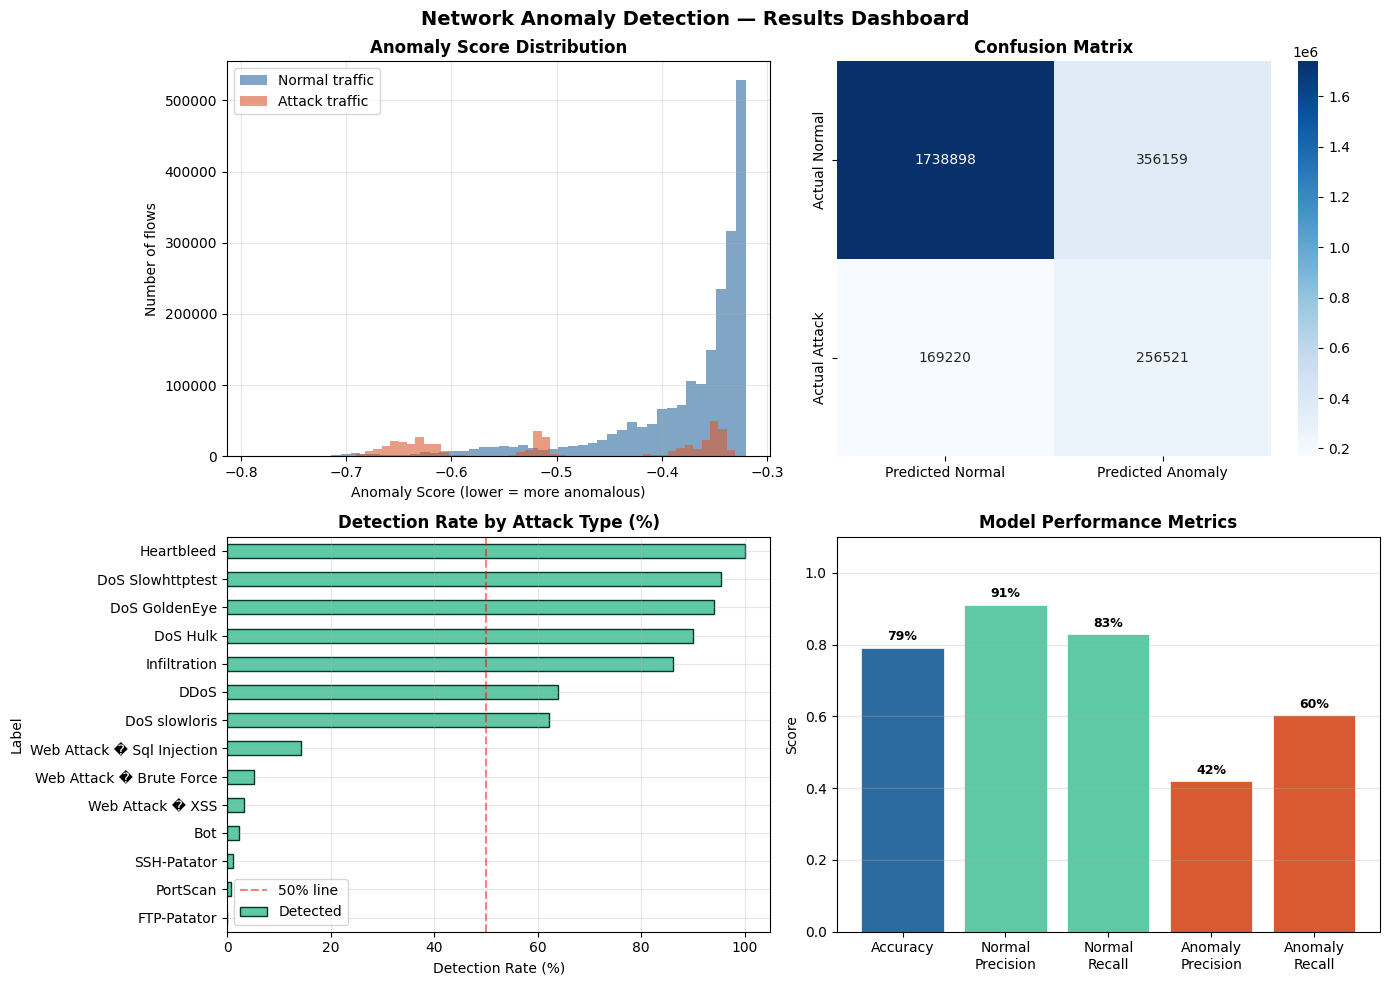

Dashboard saved to Google Drive!


In [11]:
# Step 10: Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Network Anomaly Detection — Results Dashboard',
             fontsize=14, fontweight='bold')

# ── Plot 1: Anomaly Score Distribution ──────────────────────────────
scores = model.score_samples(X_test)
axes[0,0].hist(scores[y_test==0], bins=50, alpha=0.6,
               color='#2d6a9f', label='Normal traffic')
axes[0,0].hist(scores[y_test==1], bins=50, alpha=0.6,
               color='#d85a30', label='Attack traffic')
axes[0,0].set_title('Anomaly Score Distribution', fontweight='bold')
axes[0,0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0,0].set_ylabel('Number of flows')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ── Plot 2: Confusion Matrix Heatmap ────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix', fontweight='bold')

# ── Plot 3: Attack types caught vs missed ───────────────────────────
attack_df = df[df['Label_binary'] == 1].copy()
attack_df['Detected'] = y_pred[y_test == 1]
detection_by_type = attack_df.groupby('Label')['Detected'].mean() * 100

detection_by_type.sort_values().plot(kind='barh', ax=axes[1,0],
    color='#5dcaa5', edgecolor='#04342c')
axes[1,0].set_title('Detection Rate by Attack Type (%)', fontweight='bold')
axes[1,0].set_xlabel('Detection Rate (%)')
axes[1,0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% line')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── Plot 4: Summary Metrics Bar Chart ───────────────────────────────
report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly'], output_dict=True)
metrics = ['Accuracy', 'Normal\nPrecision', 'Normal\nRecall',
           'Anomaly\nPrecision', 'Anomaly\nRecall']
values  = [report['accuracy'], report['Normal']['precision'], report['Normal']['recall'],
           report['Anomaly']['precision'], report['Anomaly']['recall']]
bar_colors = ['#2d6a9f', '#5dcaa5', '#5dcaa5', '#d85a30', '#d85a30']
bars = axes[1,1].bar(metrics, values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Model Performance Metrics', fontweight='bold')
axes[1,1].set_ylabel('Score')
axes[1,1].set_ylim(0, 1.1)
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017/anomaly_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to Google Drive!")

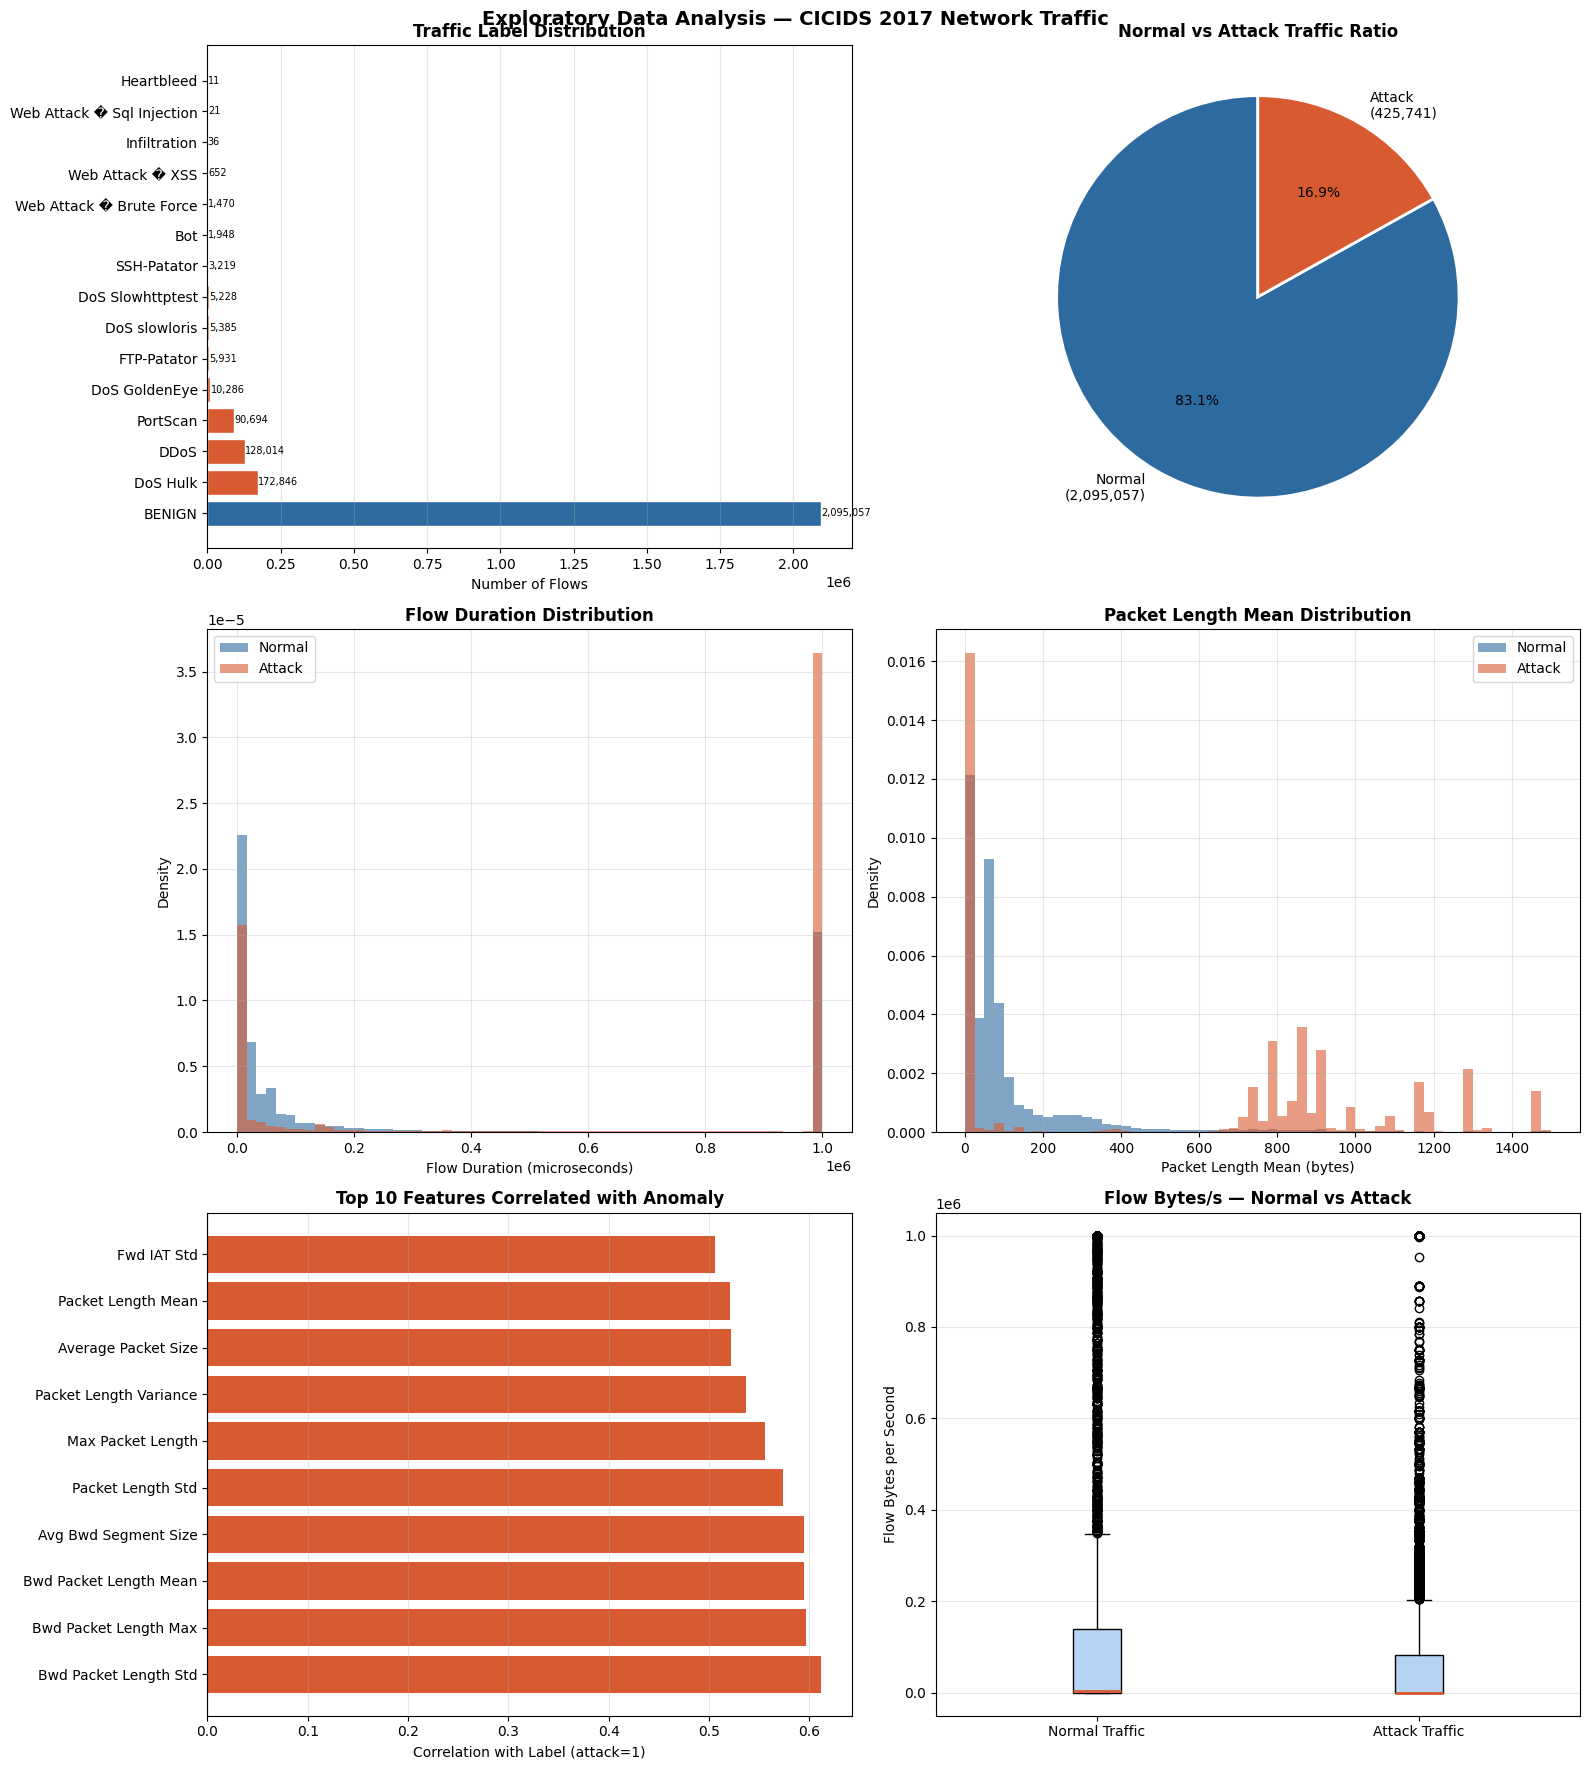

EDA visualizations saved to Google Drive!


In [12]:
# ── EDA Visualizations ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Exploratory Data Analysis — CICIDS 2017 Network Traffic',
             fontsize=14, fontweight='bold')

# ── Plot 1: Label Distribution (Attack Types) ───────────────────────
label_counts = df['Label'].value_counts()
colors_bar = ['#2d6a9f' if l == 'BENIGN' else '#d85a30'
              for l in label_counts.index]
axes[0,0].barh(label_counts.index, label_counts.values,
               color=colors_bar, edgecolor='white')
axes[0,0].set_title('Traffic Label Distribution', fontweight='bold')
axes[0,0].set_xlabel('Number of Flows')
for i, v in enumerate(label_counts.values):
    axes[0,0].text(v + 1000, i, f'{v:,}', va='center', fontsize=7)
axes[0,0].grid(True, alpha=0.3, axis='x')

# ── Plot 2: Normal vs Attack Pie Chart ──────────────────────────────
normal_count = (df['Label_binary'] == 0).sum()
attack_count = (df['Label_binary'] == 1).sum()
axes[0,1].pie([normal_count, attack_count],
              labels=[f'Normal\n({normal_count:,})',
                      f'Attack\n({attack_count:,})'],
              colors=['#2d6a9f', '#d85a30'],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title('Normal vs Attack Traffic Ratio', fontweight='bold')

# ── Plot 3: Flow Duration Distribution ──────────────────────────────
normal_dur = df[df['Label_binary']==0]['Flow Duration'].clip(0, 1e6)
attack_dur = df[df['Label_binary']==1]['Flow Duration'].clip(0, 1e6)
axes[1,0].hist(normal_dur, bins=60, alpha=0.6,
               color='#2d6a9f', label='Normal', density=True)
axes[1,0].hist(attack_dur, bins=60, alpha=0.6,
               color='#d85a30', label='Attack', density=True)
axes[1,0].set_title('Flow Duration Distribution', fontweight='bold')
axes[1,0].set_xlabel('Flow Duration (microseconds)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── Plot 4: Packet Length Mean Distribution ──────────────────────────
normal_pkt = df[df['Label_binary']==0]['Packet Length Mean'].clip(0, 1500)
attack_pkt = df[df['Label_binary']==1]['Packet Length Mean'].clip(0, 1500)
axes[1,1].hist(normal_pkt, bins=60, alpha=0.6,
               color='#2d6a9f', label='Normal', density=True)
axes[1,1].hist(attack_pkt, bins=60, alpha=0.6,
               color='#d85a30', label='Attack', density=True)
axes[1,1].set_title('Packet Length Mean Distribution', fontweight='bold')
axes[1,1].set_xlabel('Packet Length Mean (bytes)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# ── Plot 5: Top 10 Feature Correlations with Label ──────────────────
numeric_df = df.drop(columns=['Label'])
correlations = numeric_df.corr()['Label_binary'].drop('Label_binary')
top10 = correlations.abs().nlargest(10)
top10_vals = correlations[top10.index]
bar_colors = ['#d85a30' if v > 0 else '#2d6a9f' for v in top10_vals]
axes[2,0].barh(top10.index, top10_vals.values, color=bar_colors)
axes[2,0].set_title('Top 10 Features Correlated with Anomaly',
                     fontweight='bold')
axes[2,0].set_xlabel('Correlation with Label (attack=1)')
axes[2,0].axvline(x=0, color='black', linewidth=0.8)
axes[2,0].grid(True, alpha=0.3, axis='x')

# ── Plot 6: Flow Bytes/s — Normal vs Attack (boxplot) ───────────────
sample_normal = df[df['Label_binary']==0]['Flow Bytes/s'].dropna().clip(0, 1e6).sample(10000, random_state=42)
sample_attack = df[df['Label_binary']==1]['Flow Bytes/s'].dropna().clip(0, 1e6).sample(10000, random_state=42)
axes[2,1].boxplot([sample_normal, sample_attack],
                  labels=['Normal Traffic', 'Attack Traffic'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#b5d4f4'),
                  medianprops=dict(color='#d85a30', linewidth=2))
axes[2,1].set_title('Flow Bytes/s — Normal vs Attack', fontweight='bold')
axes[2,1].set_ylabel('Flow Bytes per Second')
axes[2,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017/eda_visualizations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("EDA visualizations saved to Google Drive!")